<h1 style="text-align:center;">Machine Learning: Linear Regression, Overfitting, and Regularization</h1>
<p style="text-align:center;">
Original tutorial by <b>Dr. Nazar Khan</b><br>
Modified by <b>Arbish Akram</b>
</p>

This is a tutorial on linear regression using synthetic data from a sinusoidal curve. We will use three different types of regression models:
1. Linear Regression
2. Polynomial Regression, and
3. Ridge Regression.

Each regression model uses a different form of the loss function.

This Python notebook will use common libraries like numPy, matplotlib, and scikit-learn. It will demonstrate:

- Generating data with noise from a sinusoidal function.
- Linear regression on noisy data.
- Overfitting using higher-degree polynomial features.
- Generalization by increasing the amount of data.
- Regularization using Ridge regression to avoid overfitting.
- The bias-variance tradeoff, visualized across polynomial degrees.
- The effect of the regularization strength (alpha) on Ridge regression.



### Learning Objectives

By the end of this notebook, you should be able to:

1. Explain what the hypothesis function of a linear/polynomial regression model looks like.
2. Explain how `PolynomialFeatures` transforms a single input $x$ into a feature vector $[1, x, x^2, \dots, x^d]$.
3. Distinguish between **underfitting** (high bias) and **overfitting** (high variance) using train/test error.
4. Explain, intuitively and mathematically, why adding an L2 penalty (Ridge regression) reduces overfitting.
5. Describe the effect of the regularization strength $\alpha$ on model complexity and error.

### Step 1: Generate Sinusoidal Data

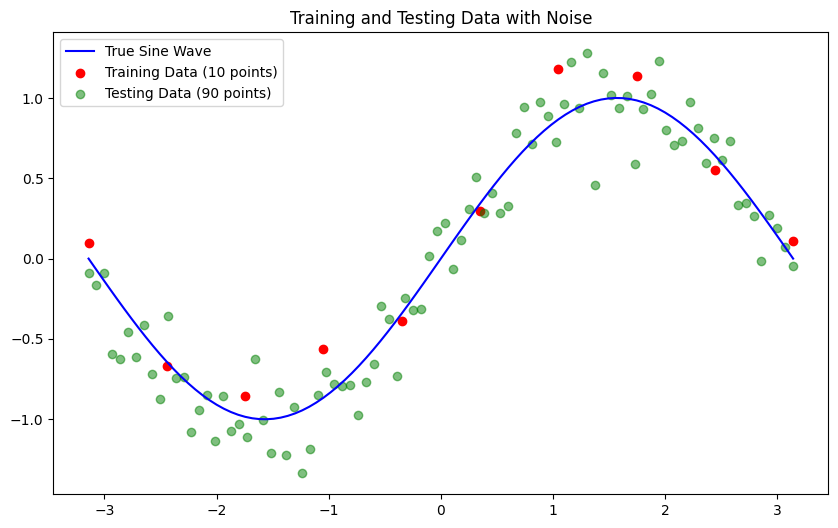

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Generate true sine wave
X_true = np.linspace(-np.pi, np.pi, 100).reshape(-1, 1)
y_true = np.sin(X_true)

# Add noise to the data for training
def generate_noisy_sinusoidal_data(n_points, noise_std):
    X = np.linspace(-np.pi, np.pi, n_points).reshape(-1, 1)
    y = np.sin(X) + np.random.normal(0, noise_std, size=X.shape)
    return X, y

# Training data (10 noisy points)
X_train, y_train = generate_noisy_sinusoidal_data(10, noise_std=0.2)

# Testing data (90 noisy points)
X_test, y_test = generate_noisy_sinusoidal_data(90, noise_std=0.2)

# Plot the true curve, training data, and testing data
plt.figure(figsize=(10, 6))
plt.plot(X_true, y_true, label='True Sine Wave', color='blue')
plt.scatter(X_train, y_train, color='red', label='Training Data (10 points)')
plt.scatter(X_test, y_test, color='green', label='Testing Data (90 points)', alpha=0.5)
plt.legend()
plt.title('Training and Testing Data with Noise')
plt.show()


**Note:** Notice that we deliberately use a *small* training set (10 points) and a *larger* test set (90 points). This mimics a common real-world situation where labeled data is scarce, and it makes overfitting easy to demonstrate: a flexible enough model can pass through all 10 training points almost perfectly while completely failing to capture the true sine wave elsewhere.

### Step 2: Linear Regression and Overfitting Example

A linear regression model with a single input feature $x$ has the hypothesis (prediction) function:

$\hat{y} = w_0 + w_1 x$

where $w_0$ is the intercept (bias term) and $w_1$ is the slope. This is a **degree-1 polynomial** in $x$ — a straight line.

Linear regression tries to minimize the Mean Squared Error (MSE) between the predicted values $\hat{y}_i$ and the actual values $y_i$.

Loss Function:

$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2$

where:

- $y_i$ are the true target values.
- $\hat{y}_i$ are the predicted values.
- $n$ is the number of data points.

Because a straight line cannot bend to follow the curvature of a sine wave, we expect this model to **underfit** the data, it will have relatively high error on *both* the training set and the test set. This is an example of high **bias**: the model's hypothesis space is too simple to represent the true relationship, no matter how the parameters are chosen.

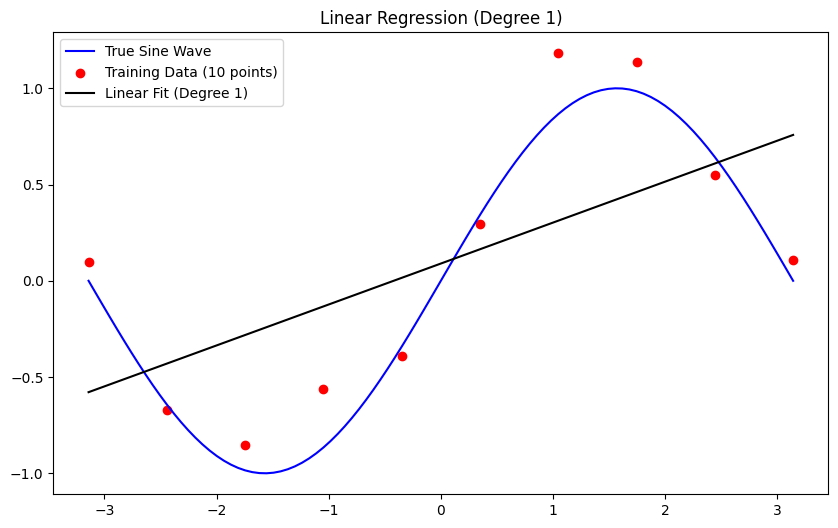

Linear Regression (Degree 1) - Training Error: 0.2851, Test Error: 0.2901


In [ ]:
# Perform linear regression (degree=1)
poly_features = PolynomialFeatures(degree=1)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.fit_transform(X_test)
X_true_poly = poly_features.fit_transform(X_true)

linear_regressor = LinearRegression()
linear_regressor.fit(X_train_poly, y_train)

# Predict for both train and test data
y_train_pred = linear_regressor.predict(X_train_poly)
y_test_pred = linear_regressor.predict(X_test_poly)
y_true_pred = linear_regressor.predict(X_true_poly)

# Plot the true curve, training points, and linear fit
plt.figure(figsize=(10, 6))
plt.plot(X_true, y_true, label='True Sine Wave', color='blue')
plt.scatter(X_train, y_train, color='red', label='Training Data (10 points)')
plt.plot(X_true, y_true_pred, label='Linear Fit (Degree 1)', color='black')
plt.legend()
plt.title('Linear Regression (Degree 1)')
plt.show()

# Evaluate the error on both train and test sets
train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_pred)
print(f"Linear Regression (Degree 1) - Training Error: {train_error:.4f}, Test Error: {test_error:.4f}")


**Observation:** Notice that the training error and the test error are both relatively high and close to each other. Neither error is small, this is the signature of **underfitting**, not overfitting. Keep this pattern in mind for comparison with the next step.

### Step 3: Overfitting using Higher Degrees

Polynomial regression is essentially linear regression with polynomial features. Instead of using just $x$ as the input, `PolynomialFeatures(degree=d)` transforms each input $x$ into a feature **vector**:

$\phi(x) = [1,\; x,\; x^2,\; x^3,\; \dots,\; x^d]$

The model then fits a **linear** combination of these polynomial features:

$\hat{y} = w_0 + w_1 x + w_2 x^2 + \dots + w_d x^d$

This is why it's called *linear* regression even though the resulting curve is nonlinear in $x$: the model is still linear in the **parameters** $w_j$, which is what `LinearRegression` actually solves for.

#### How exactly is $x$ turned into more numbers?

Before the transform, each training example is a **single number** — one scalar input $x_i$. `PolynomialFeatures` replaces that single number with a **row of powers of $x_i$**, from $x_i^0$ up to $x_i^d$. So one scalar becomes $d+1$ numbers.

Concretely, suppose one of our training points is $x = 0.5$ and we use degree $d = 3$. Then:

$\phi(0.5) = [\, 0.5^0,\; 0.5^1,\; 0.5^2,\; 0.5^3 \,] = [\, 1,\; 0.5,\; 0.25,\; 0.125 \,]$

Nothing about $x$ itself has changed — $0.5$ is still $0.5$. What has changed is that we now hand the model **four numbers instead of one**, so it has four "knobs" ($w_0, w_1, w_2, w_3$) instead of two ($w_0, w_1$) to fit the data with.

#### From a single value to a full data matrix

In the code, `X_train` is not a single number — it's a **column** of $n$ training inputs, stored as an $n \times 1$ matrix (`X_train.shape == (10, 1)` for our 10 training points). `PolynomialFeatures(degree=d).fit_transform(X_train)` applies the same $\phi(\cdot)$ mapping to *every row* of that column, turning it into an $n \times (d+1)$ matrix:

$
X_{\text{train}} =
\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}
\quad \xrightarrow{\;\phi(\cdot)\;} \quad
X_{\text{train,poly}} =
\begin{bmatrix}
1 & x_1 & x_1^2 & \dots & x_1^d \\
1 & x_2 & x_2^2 & \dots & x_2^d \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_n & x_n^2 & \dots & x_n^d
\end{bmatrix}
$

Each **row** still corresponds to one training example (one data point), but each row now has $d+1$ **columns** instead of 1. The first column is always all 1's — this is what supplies the intercept term $w_0$, so `LinearRegression` doesn't need a separate bias term.

Once the data is in this expanded form, fitting the model is *exactly* the same operation as ordinary linear regression — the only difference is that we now solve for $d+1$ weights instead of 2, by minimizing the same MSE loss:

$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2$

In our case, $d = 9$ gives a degree-9 polynomial model with **10 parameters** ($w_0, \dots, w_9$) — almost as many parameters as we have training points (10). With that much flexibility, the curve can weave through every single training point, fitting the **noise** in the training data rather than the true underlying sine pattern. This is **overfitting**, and it corresponds to high **variance**: small changes in the training sample would produce a very different fitted curve.

In [ ]:
# See the feature-vector transformation happen on real numbers

# Take a small peek: the first 3 training inputs, as plain scalars
print("Original X_train (first 3 rows), shape", X_train[:3].shape, ":\n", X_train[:3])

# Transform with a small degree first so the numbers are easy to read
demo_features = PolynomialFeatures(degree=3)
X_demo_poly = demo_features.fit_transform(X_train[:3])

print("\nSame 3 rows after PolynomialFeatures(degree=3), shape", X_demo_poly.shape, ":\n", X_demo_poly)
print("\nColumn meaning:", demo_features.get_feature_names_out(['x']))

# Sanity check: column 0 is always 1 (x^0), column 1 equals the original x (x^1)
print("\nColumn 0 (x^0) is all ones:", X_demo_poly[:, 0])
print("Column 1 (x^1) equals original x:", X_demo_poly[:, 1])
print("Column 2 (x^2):", X_demo_poly[:, 2], " -- should equal x^2 =", (X_train[:3, 0])**2)
print("Column 3 (x^3):", X_demo_poly[:, 3], " -- should equal x^3 =", (X_train[:3, 0])**3)


Original X_train (first 3 rows), shape (3, 1) :
 [[-3.14159265]
 [-2.44346095]
 [-1.74532925]]

Same 3 rows after PolynomialFeatures(degree=3), shape (3, 4) :
 [[  1.          -3.14159265   9.8696044  -31.00627668]
 [  1.          -2.44346095   5.97050143 -14.58868711]
 [  1.          -1.74532925   3.0461742   -5.31657693]]

Column meaning: ['1' 'x' 'x^2' 'x^3']

Column 0 (x^0) is all ones: [1. 1. 1.]
Column 1 (x^1) equals original x: [-3.14159265 -2.44346095 -1.74532925]
Column 2 (x^2): [9.8696044  5.97050143 3.0461742 ]  -- should equal x^2 = [9.8696044  5.97050143 3.0461742 ]
Column 3 (x^3): [-31.00627668 -14.58868711  -5.31657693]  -- should equal x^3 = [-31.00627668 -14.58868711  -5.31657693]


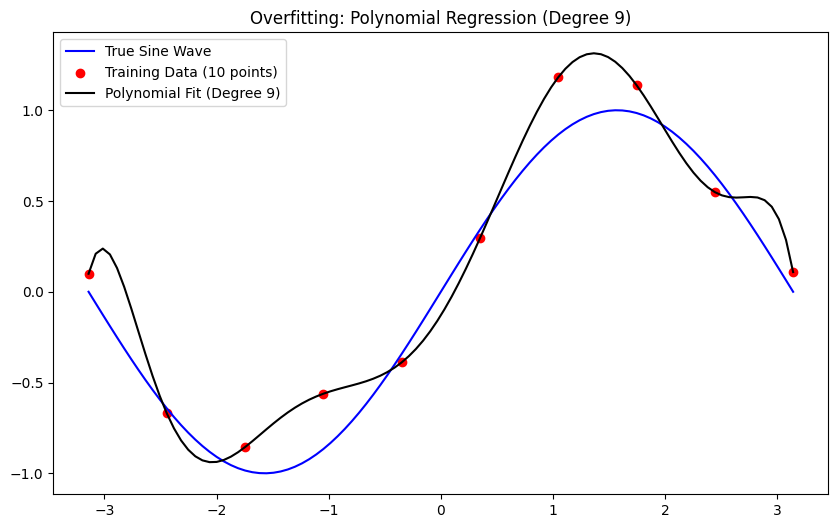

Polynomial Regression (Degree 9) - Training Error: 0.0000, Test Error: 0.0872
Learned parameters:
 [[ 0.00000000e+00  9.99205043e-01  7.20559275e-01 -1.60028853e-01
  -3.47418446e-01  7.76212594e-03  5.39971162e-02 -5.65879676e-04
  -2.62935014e-03  3.89527864e-05]]
Magnitude of learned parameters vector:  1.2910880572632466


In [ ]:
# Try polynomial regression with a higher degree (degree=9)
poly_features = PolynomialFeatures(degree=9)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.fit_transform(X_test)
X_true_poly = poly_features.fit_transform(X_true)

poly_regressor = LinearRegression()
poly_regressor.fit(X_train_poly, y_train)

# Predict for both train and test data
y_train_pred_poly = poly_regressor.predict(X_train_poly)
y_test_pred_poly = poly_regressor.predict(X_test_poly)
y_true_pred_poly = poly_regressor.predict(X_true_poly)

# Plot the true curve, training points, and high-degree polynomial fit
plt.figure(figsize=(10, 6))
plt.plot(X_true, y_true, label='True Sine Wave', color='blue')
plt.scatter(X_train, y_train, color='red', label='Training Data (10 points)')
plt.plot(X_true, y_true_pred_poly, label='Polynomial Fit (Degree 9)', color='black')
plt.legend()
plt.title('Overfitting: Polynomial Regression (Degree 9)')
plt.show()

# Evaluate the error on both train and test sets
train_error_poly = mean_squared_error(y_train, y_train_pred_poly)
test_error_poly = mean_squared_error(y_test, y_test_pred_poly)
print(f"Polynomial Regression (Degree 9) - Training Error: {train_error_poly:.4f}, Test Error: {test_error_poly:.4f}")
print("Learned parameters:\n", poly_regressor.coef_)
print("Magnitude of learned parameters vector: ", np.linalg.norm(poly_regressor.coef_))


**Observation:** The training error should now be very close to zero — the curve passes almost exactly through the 10 training points. But the test error is typically *much* larger than in Step 2, and the plotted curve swings wildly between training points, especially near the edges of the input range. Also look at the magnitude of the learned parameter vector: it is typically **much larger** than in the degree-1 case. Large-magnitude weights are a common symptom of overfitting, and this is exactly what regularization (Step 5) will try to control.

### Step 3b: Visualizing the Bias-Variance Tradeoff Across Degrees

Rather than only comparing degree 1 (underfitting) and degree 9 (overfitting), it is useful to see how training and test error change as the polynomial degree increases. This is one of the most common diagnostic plots in machine learning.

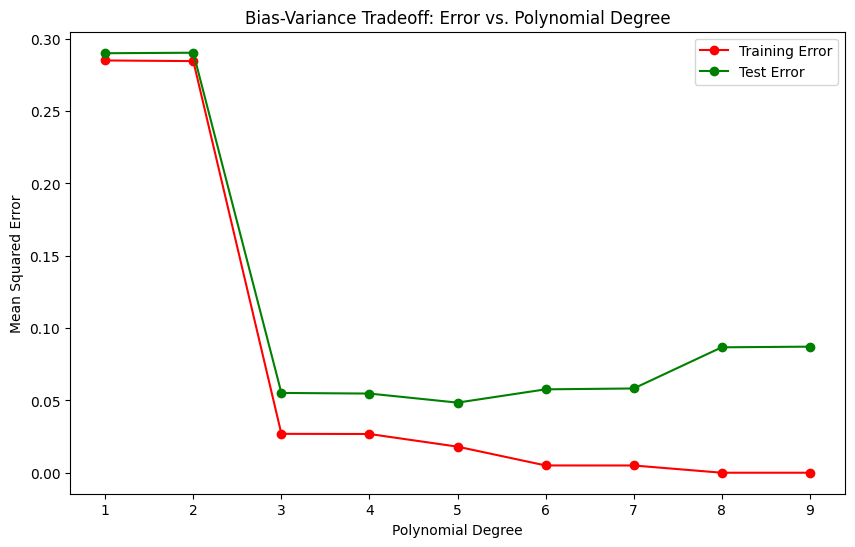

Degree 1: Train Error = 0.2851, Test Error = 0.2901
Degree 2: Train Error = 0.2846, Test Error = 0.2904
Degree 3: Train Error = 0.0269, Test Error = 0.0552
Degree 4: Train Error = 0.0268, Test Error = 0.0547
Degree 5: Train Error = 0.0180, Test Error = 0.0485
Degree 6: Train Error = 0.0050, Test Error = 0.0577
Degree 7: Train Error = 0.0050, Test Error = 0.0583
Degree 8: Train Error = 0.0000, Test Error = 0.0867
Degree 9: Train Error = 0.0000, Test Error = 0.0872


In [ ]:
# Compare training and test error across a range of polynomial degrees
degrees = list(range(1, 10))
train_errors = []
test_errors = []

for d in degrees:
    pf = PolynomialFeatures(degree=d)
    Xtr = pf.fit_transform(X_train)
    Xte = pf.transform(X_test)

    model = LinearRegression()
    model.fit(Xtr, y_train)

    train_errors.append(mean_squared_error(y_train, model.predict(Xtr)))
    test_errors.append(mean_squared_error(y_test, model.predict(Xte)))

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'o-', label='Training Error', color='red')
plt.plot(degrees, test_errors, 'o-', label='Test Error', color='green')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Tradeoff: Error vs. Polynomial Degree')
plt.legend()
plt.show()

for d, tr, te in zip(degrees, train_errors, test_errors):
    print(f"Degree {d}: Train Error = {tr:.4f}, Test Error = {te:.4f}")


**How to read this plot:**

- **Low degree (left side):** Training error and test error are both high and close together → **underfitting / high bias**.
- **High degree (right side):** Training error keeps decreasing (often toward zero), but test error rises sharply → **overfitting / high variance**.
- The degree where test error is lowest represents the best tradeoff between bias and variance **for this particular small training set**. In practice we choose model complexity using a validation set or cross-validation, not by peeking at the test set directly.

### Step 4: Generalization by Using More Data

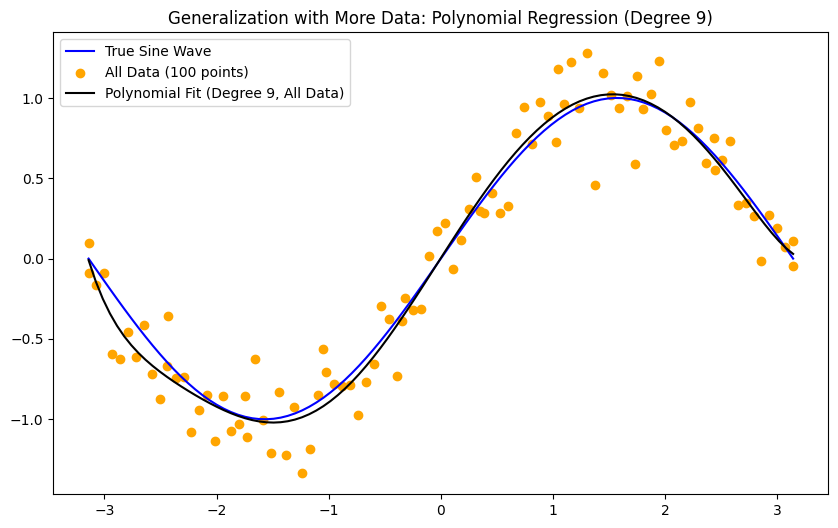

Polynomial Regression (Degree 9, All Data) - Error: 0.0302
Learned parameters:
 [[ 0.00000000e+00  1.09092823e+00 -2.50223455e-02 -2.20194420e-01
   1.94987659e-02  1.86304373e-02 -4.60201476e-03 -7.84802001e-04
   2.92823313e-04  2.97015333e-06]]
Magnitude of learned parameters vector:  1.1135462590922378


In [ ]:
# Use both training and testing data (100 points) to prevent overfitting
X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

poly_features = PolynomialFeatures(degree=9)
X_all_poly = poly_features.fit_transform(X_all)
X_true_poly = poly_features.fit_transform(X_true)

poly_regressor.fit(X_all_poly, y_all)

# Predict for the full dataset
y_true_pred_all = poly_regressor.predict(X_true_poly)

# Plot the true curve and new polynomial fit (using 100 points)
plt.figure(figsize=(10, 6))
plt.plot(X_true, y_true, label='True Sine Wave', color='blue')
plt.scatter(X_all, y_all, color='orange', label='All Data (100 points)')
plt.plot(X_true, y_true_pred_all, label='Polynomial Fit (Degree 9, All Data)', color='black')
plt.legend()
plt.title('Generalization with More Data: Polynomial Regression (Degree 9)')
plt.show()

# Evaluate the error on the larger dataset
train_error_all = mean_squared_error(y_all, poly_regressor.predict(X_all_poly))
print(f"Polynomial Regression (Degree 9, All Data) - Error: {train_error_all:.4f}")
print("Learned parameters:\n", poly_regressor.coef_)
print("Magnitude of learned parameters vector: ", np.linalg.norm(poly_regressor.coef_))

**Observation:** With 100 points instead of 10, the same degree-9 model can no longer perfectly memorize every point (there are more constraints than free parameters, relative to before), so it is forced to find a curve that fits the *general trend* rather than the noise. The learned parameter magnitudes are typically much smaller than in Step 3, and the fitted curve should look visibly closer to the true sine wave.

Overfitting is not only about model complexity, it is about model complexity **relative to the amount of available data**. A degree-9 model overfits with 10 points but can generalize reasonably well with 100 points.

### Step 5: Generalization Using Ridge Regularization

Adding more data is one way to fight overfitting, but often we cannot collect more data. **Regularization** is an alternative: instead of changing the data, we change the loss function so that the optimizer is discouraged from choosing large weights.

Ridge regression modifies the linear (or polynomial) regression loss by adding a penalty term proportional to the squared magnitude of the weights.

Loss Function:

$\text{Ridge Loss} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 + \alpha \sum_{j=1}^{p} w_j^2$

where:

- $\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2$ is the MSE (data-fitting term).
- $\sum_{j=1}^{p} w_j^2$ is the **L2 regularization term** (also called weight decay), the squared Euclidean norm of the weight vector, excluding the bias/intercept $w_0$.
- $\alpha \geq 0$ is a regularization hyperparameter controlling the strength of the penalty.
- $w_j$ are the model parameters (weights), $p$ is the number of weights.

**Why does penalizing large weights reduce overfitting?** In Step 3 we saw that the overfitted degree-9 model needed very large-magnitude weights (with alternating signs) to bend sharply enough to pass through every noisy training point. By adding $\alpha \sum_j w_j^2$ to the loss, we make such large weights *expensive* — the optimizer will only choose them if the resulting reduction in MSE is worth the penalty. This has the effect of "smoothing out" the fitted curve.

**The role of $\alpha$:**

- $\alpha = 0$: Ridge regression reduces to ordinary linear regression (no regularization).
- Small $\alpha$: mild shrinkage of the weights, small effect on the fitted curve.
- Large $\alpha$: strong shrinkage; weights are pushed toward zero, and the model becomes simpler (closer to a flat line) — too large an $\alpha$ can cause **underfitting**.

Choosing $\alpha$ is itself a bias-variance tradeoff, usually tuned using a validation set or cross-validation.

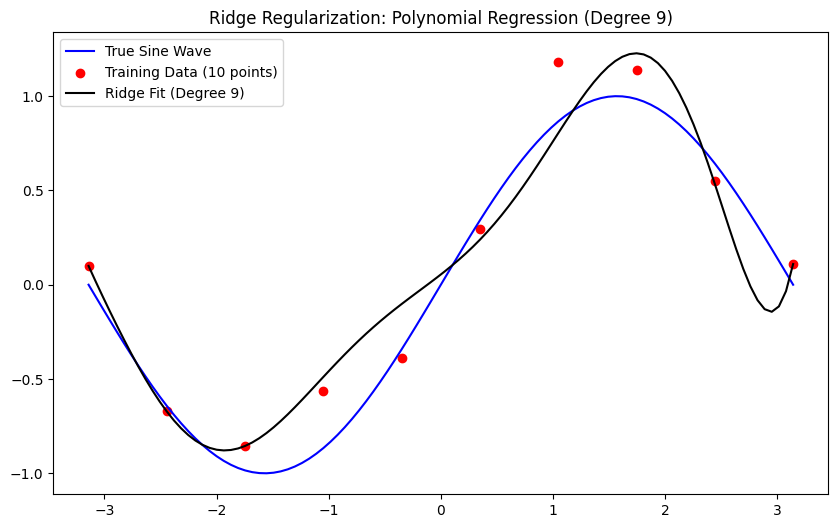

Ridge Regression (Degree 9) - Training Error: 0.0242, Test Error: 0.0843
Learned parameters:
 [ 0.00000000e+00  4.63903732e-01  1.18176869e-01  2.10992013e-01
 -1.91123181e-02 -7.09832072e-02 -2.94433406e-03  5.57267043e-03
  3.76903355e-04 -1.04106240e-04]
Magnitude of learned parameters vector:  0.5283311914955211


In [ ]:
# Ridge regression with regularization (L2 penalty)
ridge_regressor = Ridge(alpha=1.0)
ridge_regressor.fit(X_train_poly, y_train)

# Predict for train, test, and true data
y_train_pred_ridge = ridge_regressor.predict(X_train_poly)
y_test_pred_ridge = ridge_regressor.predict(X_test_poly)
y_true_pred_ridge = ridge_regressor.predict(X_true_poly)

# Plot the true curve, training points, and Ridge regression fit
plt.figure(figsize=(10, 6))
plt.plot(X_true, y_true, label='True Sine Wave', color='blue')
plt.scatter(X_train, y_train, color='red', label='Training Data (10 points)')
plt.plot(X_true, y_true_pred_ridge, label='Ridge Fit (Degree 9)', color='black')
plt.legend()
plt.title('Ridge Regularization: Polynomial Regression (Degree 9)')
plt.show()

# Evaluate the error with Ridge regularization
train_error_ridge = mean_squared_error(y_train, y_train_pred_ridge)
test_error_ridge = mean_squared_error(y_test, y_test_pred_ridge)
print(f"Ridge Regression (Degree 9) - Training Error: {train_error_ridge:.4f}, Test Error: {test_error_ridge:.4f}")
print("Learned parameters:\n", ridge_regressor.coef_)
print("Magnitude of learned parameters vector: ", np.linalg.norm(ridge_regressor.coef_))


**Note:** This cell reuses `X_train_poly` and `X_test_poly` from Step 3, which were built with `degree=9`. Make sure you have run the Step 3 cell first so these variables refer to the degree-9 feature matrices before running Ridge here.

### Step 5b: Effect of the Regularization Strength $\alpha$

Let's directly observe what happens to the fitted curve and to train/test error as we sweep $\alpha$ from very small (almost no regularization) to very large (heavy regularization), using the degree-9 features.

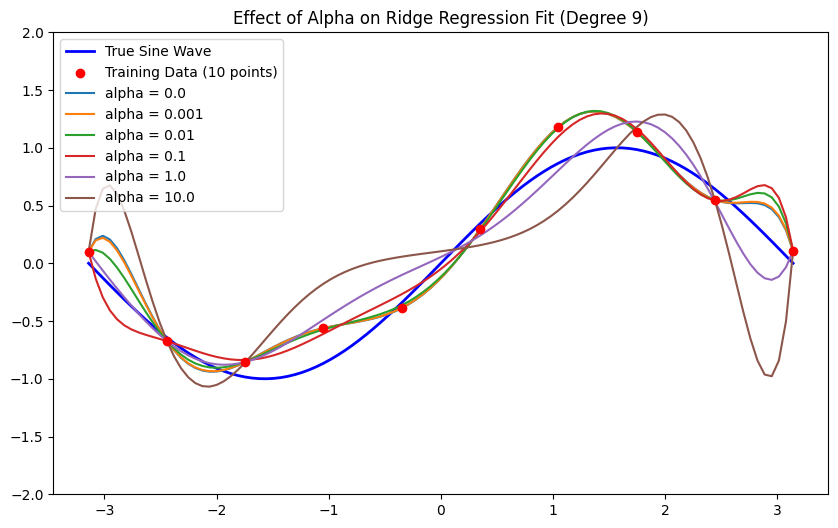

   alpha |  Train MSE |   Test MSE |      ||w||
------------------------------------------------
     0.0 |     0.0000 |     0.0872 |     1.2911
   0.001 |     0.0000 |     0.0862 |     1.2809
    0.01 |     0.0001 |     0.0810 |     1.2065
     0.1 |     0.0026 |     0.0710 |     0.9305
     1.0 |     0.0242 |     0.0843 |     0.5283
    10.0 |     0.0893 |     0.2865 |     0.1857


In [ ]:
# Sweep alpha and observe the effect on the fitted curve
alphas = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0]

plt.figure(figsize=(10, 6))
plt.plot(X_true, y_true, label='True Sine Wave', color='blue', linewidth=2)
plt.scatter(X_train, y_train, color='red', label='Training Data (10 points)', zorder=5)

for a in alphas:
    model = Ridge(alpha=a) if a > 0 else LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_true_poly)
    plt.plot(X_true, y_pred, label=f'alpha = {a}')

plt.ylim(-2, 2)
plt.legend()
plt.title('Effect of Alpha on Ridge Regression Fit (Degree 9)')
plt.show()

# Sweep alpha and record train/test error and weight norm
print(f"{'alpha':>8} | {'Train MSE':>10} | {'Test MSE':>10} | {'||w||':>10}")
print('-' * 48)
for a in alphas:
    model = Ridge(alpha=a) if a > 0 else LinearRegression()
    model.fit(X_train_poly, y_train)
    tr_err = mean_squared_error(y_train, model.predict(X_train_poly))
    te_err = mean_squared_error(y_test, model.predict(X_test_poly))
    w_norm = np.linalg.norm(model.coef_)
    print(f"{a:>8} | {tr_err:>10.4f} | {te_err:>10.4f} | {w_norm:>10.4f}")


**Observation:** As $\alpha$ increases:

- The weight norm $\lVert w \rVert$ shrinks, this is the regularization directly doing its job.
- Training error tends to increase slightly (the model fits the training points less exactly).
- Test error typically improves up to a point, then gets worse again once $\alpha$ becomes so large that the model is too constrained to capture the true curve (underfitting).

This mirrors the bias-variance plot from Step 3b, but now the x-axis is $\alpha$ instead of polynomial degree — both are ways of controlling model complexity.

### Summary of Loss Functions
- **Linear Regression:** Minimizes the Mean Squared Error (MSE). Model: $\hat{y} = w_0 + w_1 x$.
- **Polynomial Regression:** Same MSE loss as linear regression, but applied to polynomial features $[1, x, x^2, \dots, x^d]$. Increasing $d$ increases model flexibility (and risk of overfitting).
- **Ridge Regression:** Minimizes MSE with an additional L2 regularization term $\alpha \sum_j w_j^2$ to penalize large weights and prevent overfitting.

### Comparison Table (Degree 9 models, 10 training points)

| Model | Training Error | Test Error | Weight Norm |
|---|---|---|---|
| Polynomial (no regularization) | Very low (~0) | High | Very large |
| Polynomial + more data (100 pts) | Low | Lower | Moderate |
| Ridge (alpha = 1.0) | Slightly higher than unregularized | Lower than unregularized | Small |

*(Run the notebook to fill in the exact numbers for your random seed.)*

### Exercises

1. Rerun Step 1 with `noise_std=0.5`. How does the increased noise affect overfitting for the degree-9 model?
2. In Step 3b, add degree values up to 15. Does the test error keep increasing, or does it eventually plateau? Why might that happen given how `PolynomialFeatures` behaves for very high degrees on this input range?
3. Modify the training set size in Step 1 (e.g., 5, 20, 50 points) and rerun Step 3b's degree sweep for each. How does the optimal degree (lowest test error) change as the training set grows?
